<a href="https://www.kaggle.com/code/nischalgirii/predicting-earthquake-magnitude-and-severity-in-ne?scriptVersionId=313226256" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

        path = "/kaggle/input/datasets/sangampaudel530/nepal-earthquakes-20152025"

for file in os.listdir(path):
    print(file)

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/sangampaudel530/nepal-earthquakes-20152025/nepal_earthquakes_2015_2025.csv
nepal_earthquakes_2015_2025.csv


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Regression and Classification Models
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet, LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier, DecisionTreeRegressor
from sklearn.ensemble import RandomForestClassifier

# Preprocessing and Metrics
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, PolynomialFeatures, TargetEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_squared_error, r2_score, accuracy_score, confusion_matrix, ConfusionMatrixDisplay



In [3]:
# load the dataset
df = pd.read_csv(os.path.join(path, file))
df.head()

,Date,Time,Magnitude,Depth_km,Longitude,Latitude,Place
0,2015-01-05,19:41:44.280000,4.2,34.47,81.6126,28.8652,"9 km WNW of Dailekh, Nepal"
1,2015-01-22,03:42:38.040000,4.0,40.66,81.0522,29.3853,"17 km NE of Dipayal, Nepal"
2,2015-01-31,13:59:45.250000,4.8,32.41,83.9732,28.2987,"3 km N of Pokhara, Nepal"
3,2015-04-02,00:56:38.960000,4.6,57.33,86.3309,28.7007,"89 km NNE of Kod?ri??, Nepal"
4,2015-04-21,14:02:15.550000,5.0,10.00,82.3938,28.8947,"46 km SSE of Jumla, Nepal"


In [4]:
# data cleaning
df.isnull().sum()

Date         0
Time         0
Magnitude    0
Depth_km     0
Longitude    0
Latitude     0
Place        0
dtype: int64

In [5]:
df['Place'].unique

<bound method Series.unique of 0        9 km WNW of Dailekh, Nepal
1        17 km NE of Dipayal, Nepal
2          3 km N of Pokhara, Nepal
3      89 km NNE of Kod?ri??, Nepal
4         46 km SSE of Jumla, Nepal
                   ...             
647    120 km NNE of Lobuche, Nepal
648      118 km N of Lobuche, Nepal
649      81 km NE of Lobuche, Nepal
650      94 km NNW of Mangan, India
651      138 km N of Lobuche, Nepal
Name: Place, Length: 652, dtype: object>

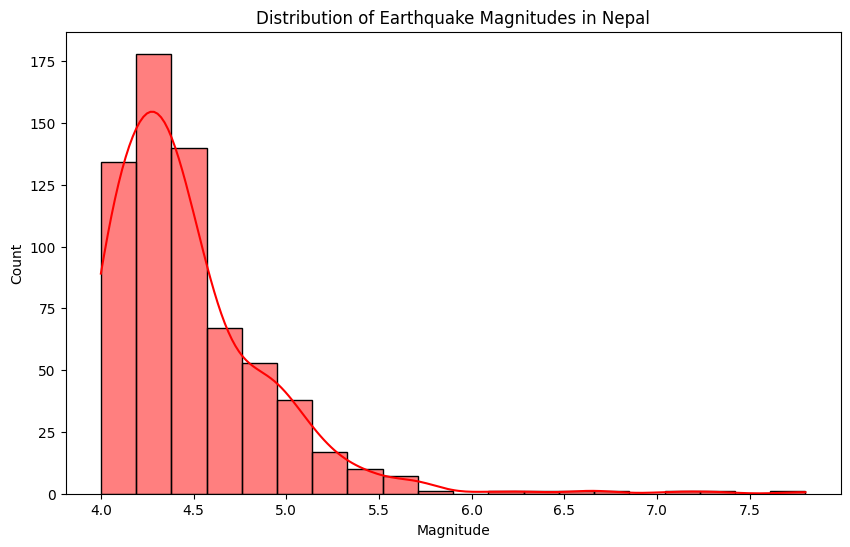

In [6]:
plt.figure(figsize=(10,6))
sns.histplot(df['Magnitude'], bins=20, kde=True, color='red')
plt.title('Distribution of Earthquake Magnitudes in Nepal')
plt.show()



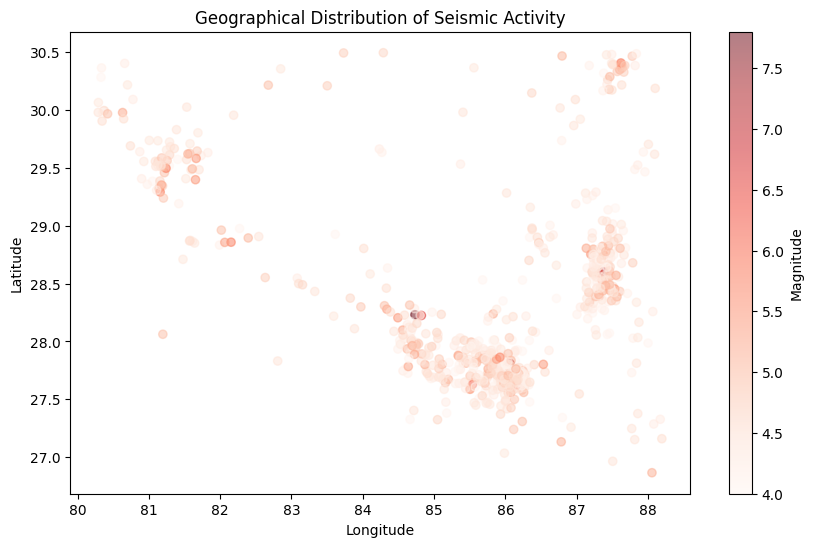

In [7]:
plt.figure(figsize=(10,6))
plt.scatter(df['Longitude'], df['Latitude'], c=df['Magnitude'], cmap='Reds', alpha=0.5)
plt.colorbar(label='Magnitude')
plt.title('Geographical Distribution of Seismic Activity')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.show()

Data Encoding


In [8]:
# 1. Temporal Feature Extraction
df['Timestamp'] = pd.to_datetime(df['Date'] + ' ' + df['Time'], format='mixed')
df['Year'] = df['Timestamp'].dt.year
df['Month'] = df['Timestamp'].dt.month
df['Hour'] = df['Timestamp'].dt.hour

In [9]:
# 2. Extract District (Encoding Context)
df['District'] = df['Place'].str.split(',').str[-1].str.strip()

In [10]:
# 3. Define Severity for Classification
def get_severity(mag):
    if mag <= 4.3: return 0  # Light
    elif mag <= 4.8: return 1 # Moderate
    else: return 2            # Strong

df['Severity'] = df['Magnitude'].apply(get_severity)

In [11]:
# Select features for models
numeric_features = ['Depth_km', 'Longitude', 'Latitude', 'Year', 'Month', 'Hour']
categorical_features = ['District']
X = df[numeric_features + categorical_features]

Regression Analysis
We implement SLR, MLR, and Regularization (L1/L2) using Scikit-Learn Pipelines.

In [12]:
y_reg = df['Magnitude']
X_train, X_test, y_train, y_test = train_test_split(X, y_reg, test_size=0.2, random_state=42)

# Define Preprocessing Pipeline
preprocessor = ColumnTransformer([
    ('num', StandardScaler(), numeric_features),
    ('cat', TargetEncoder(), categorical_features)
])

# Define Regression Models
reg_models = {
    'MLR': LinearRegression(),
    'Ridge (L2)': Ridge(alpha=1.0),
    'Lasso (L1)': Lasso(alpha=0.01),
    'ElasticNet': ElasticNet(alpha=0.01, l1_ratio=0.5)
}

print("--- Regression Performance Metrics ---")
for name, model in reg_models.items():
    pipe = Pipeline([('pre', preprocessor), ('model', model)])
    pipe.fit(X_train, y_train)
    y_pred = pipe.predict(X_test)
    print(f"{name:12} | MSE: {mean_squared_error(y_test, y_pred):.4f} | R2: {r2_score(y_test, y_pred):.4f}")

# Polynomial Regression (PLR)
plr_pipe = Pipeline([('pre', preprocessor), ('poly', PolynomialFeatures(degree=2)), ('model', LinearRegression())])
plr_pipe.fit(X_train, y_train)
print(f"{'PLR (Deg 2)':12} | MSE: {mean_squared_error(y_test, plr_pipe.predict(X_test)):.4f} | R2: {r2_score(y_test, plr_pipe.predict(X_test)):.4f}")

--- Regression Performance Metrics ---
MLR          | MSE: 0.2462 | R2: -0.0087
Ridge (L2)   | MSE: 0.2451 | R2: -0.0042
Lasso (L1)   | MSE: 0.2453 | R2: -0.0051
ElasticNet   | MSE: 0.2450 | R2: -0.0039
PLR (Deg 2)  | MSE: 0.2529 | R2: -0.0361


Classification Analysis (Predicting Severity)
We implement the requested classification algorithms to categorize seismic risk.

In [13]:
y_clf = df['Severity']
X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(X, y_clf, test_size=0.2, random_state=42, stratify=y_clf)

clf_models = {
    'Logistic Regression': LogisticRegression(max_iter=1000),
    'KNN': KNeighborsClassifier(n_neighbors=5),
    'Naive Bayes': GaussianNB(),
    'SVM': SVC(),
    'Decision Tree': DecisionTreeClassifier(),
    'Random Forest': RandomForestClassifier(n_estimators=100)
}

print("\n--- Classification Accuracy ---")
for name, model in clf_models.items():
    pipe = Pipeline([('pre', preprocessor), ('model', model)])
    pipe.fit(X_train_c, y_train_c)
    acc = accuracy_score(y_test_c, pipe.predict(X_test_c))
    print(f"{name:20} | Accuracy: {acc:.4f}")


--- Classification Accuracy ---
Logistic Regression  | Accuracy: 0.4809
KNN                  | Accuracy: 0.5038
Naive Bayes          | Accuracy: 0.3053
SVM                  | Accuracy: 0.4809
Decision Tree        | Accuracy: 0.4351
Random Forest        | Accuracy: 0.4351


As our accuracy <=50 , all the prediction are invalid. KNN has the highest percentage of accuracy with 50.38% which is weak learner.

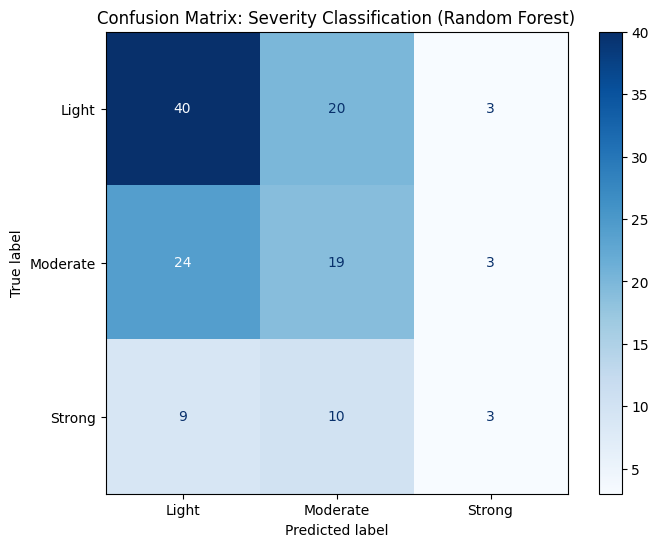


Detailed Classification Report:

              precision    recall  f1-score   support

       Light       0.55      0.63      0.59        63
    Moderate       0.39      0.41      0.40        46
      Strong       0.33      0.14      0.19        22

    accuracy                           0.47       131
   macro avg       0.42      0.39      0.39       131
weighted avg       0.46      0.47      0.46       131



In [14]:
from sklearn.metrics import classification_report, ConfusionMatrixDisplay, accuracy_score

# Train Final Ensemble Model
final_model = Pipeline([('pre', preprocessor), ('model', RandomForestClassifier())])
final_model.fit(X_train_c, y_train_c)
y_pred_final = final_model.predict(X_test_c)

# Plot Confusion Matrix
fig, ax = plt.subplots(figsize=(8, 6))
ConfusionMatrixDisplay.from_predictions(y_test_c, y_pred_final, 
                                        display_labels=['Light', 'Moderate', 'Strong'], 
                                        cmap='Blues', ax=ax)
plt.title("Confusion Matrix: Severity Classification (Random Forest)")
plt.show()

# Classification Report
print("\nDetailed Classification Report:\n")
# Now this will work!
print(classification_report(y_test_c, y_pred_final, target_names=['Light', 'Moderate', 'Strong']))